In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Connected!")

Connected!


In [4]:
# Load everything from our database into a dataframe
query = """
    SELECT 
        sp.ticker,
        sp.date,
        sp.open,
        sp.close,
        sp.high,
        sp.low,
        sp.volume,
        c.company_name,
        s.sector_name
    FROM stock_prices sp
    JOIN companies c ON sp.ticker = c.ticker
    JOIN sectors s ON c.sector_id = s.sector_id
    ORDER BY sp.ticker, sp.date
"""

df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
print(df.head())

(2520, 9)
  ticker       date        open       close        high         low    volume  \
0   AAPL 2025-03-25  219.811973  222.779037  223.127525  219.124965  34493600   
1   AAPL 2025-03-26  222.540068  220.568665  224.043525  219.513267  34466100   
2   AAPL 2025-03-27  220.429300  222.878632  224.013684  219.602900  37094800   
3   AAPL 2025-03-28  220.708051  216.954407  222.838764  216.735360  39818600   
4   AAPL 2025-03-31  216.068284  221.166077  224.640922  215.291670  65299300   

  company_name sector_name  
0   Apple Inc.  Technology  
1   Apple Inc.  Technology  
2   Apple Inc.  Technology  
3   Apple Inc.  Technology  
4   Apple Inc.  Technology  


In [ ]:
# Calculate percentage change from first day to last day for each ticker
performance = df.groupby('company_name').apply(
    lambda x: ((x.loc[x['date'].idxmax(), 'close'] - x.loc[x['date'].idxmin(), 'close']) 
               / x.loc[x['date'].idxmin(), 'close']) * 100,
    include_groups=False
).reset_index()

performance.columns = ['company_name', 'yearly_return_pct']
performance = performance.sort_values('yearly_return_pct', ascending=False)

fig = px.bar(
    performance,
    x='company_name',
    y='yearly_return_pct',
    color='yearly_return_pct',
    color_continuous_scale='RdYlGn',
    title='📈 Yearly Return by Stock (%)',
    labels={'yearly_return_pct': 'Return (%)'}
)
fig.show()

In [ ]:
# Merge performance with sector info
sector_perf = df.groupby(['ticker', 'sector_name']).apply(
    lambda x: ((x.loc[x['date'].idxmax(), 'close'] - x.loc[x['date'].idxmin(), 'close'])
               / x.loc[x['date'].idxmin(), 'close']) * 100,
    include_groups=False
).reset_index()

sector_perf.columns = ['ticker', 'sector_name', 'return_pct']

# Average return per sector
sector_avg = sector_perf.groupby('sector_name')['return_pct'].mean().reset_index()
sector_avg = sector_avg.sort_values('return_pct', ascending=False)

fig = px.bar(
    sector_avg,
    x='sector_name',
    y='return_pct',
    color='return_pct',
    color_continuous_scale='RdYlGn',
    title='🏭 Average Return by Sector (%)',
    labels={'return_pct': 'Avg Return (%)', 'sector_name': 'Sector'}
)
fig.show()

In [ ]:
from plotly.subplots import make_subplots

df = df.sort_values(['ticker', 'date'])
df['ma_30'] = df.groupby('ticker')['close'].transform(lambda x: x.rolling(30).mean())

tickers = df['ticker'].unique()

fig = make_subplots(
    rows=5, cols=2,
    subplot_titles=tickers,
    shared_xaxes=False
)

colors = px.colors.qualitative.Plotly

for i, ticker in enumerate(tickers):
    row = i // 2 + 1
    col = i % 2 + 1
    ticker_df = df[df['ticker'] == ticker]
    color = colors[i]

    # Close price — solid
    fig.add_trace(go.Scatter(
        x=ticker_df['date'],
        y=ticker_df['close'],
        name=f'{ticker} Close',
        mode='lines',
        line=dict(color=color, width=1.5),
        showlegend=True
    ), row=row, col=col)

    # MA30 — dashed
    fig.add_trace(go.Scatter(
        x=ticker_df['date'],
        y=ticker_df['ma_30'],
        name=f'{ticker} MA30',
        mode='lines',
        line=dict(color=color, width=1.5, dash='dash'),
        showlegend=True
    ), row=row, col=col)

fig.update_layout(
    height=1400,
    title_text='📉 Stock Price vs 30-Day Moving Average',
    hovermode='x unified'
)
fig.show()

In [ ]:
# Volatility = standard deviation of daily returns
df['daily_return'] = df.groupby('ticker')['close'].pct_change()

volatility = df.groupby('ticker')['daily_return'].std().reset_index()
volatility.columns = ['ticker', 'volatility']
volatility['volatility_pct'] = volatility['volatility'] * 100
volatility = volatility.sort_values('volatility_pct', ascending=False)

fig = px.bar(
    volatility,
    x='ticker',
    y='volatility_pct',
    color='volatility_pct',
    color_continuous_scale='Reds',
    title='⚡ Stock Volatility (Std Dev of Daily Returns %)',
    labels={'volatility_pct': 'Volatility (%)'}
)
fig.show()

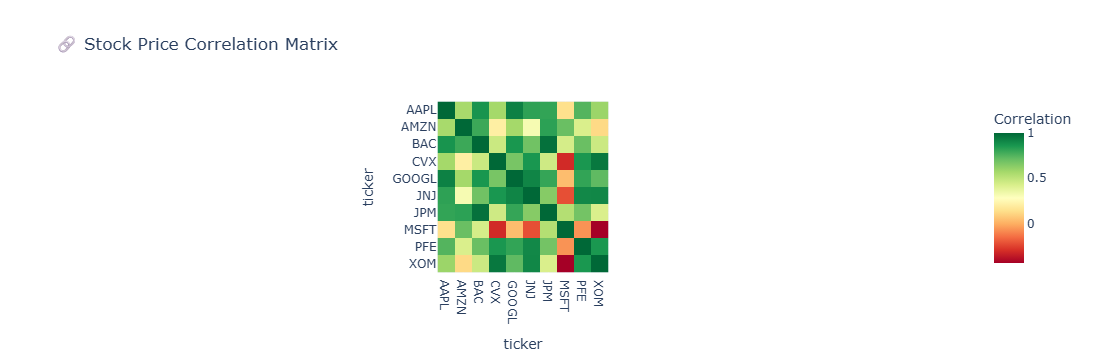

In [33]:
# Pivot to get each ticker as a column
price_pivot = df.pivot(index='date', columns='ticker', values='close')

# Calculate correlation matrix
correlation = price_pivot.corr()

fig = px.imshow(
    correlation,
    color_continuous_scale='RdYlGn',
    title='🔗 Stock Price Correlation Matrix',
    labels={'color': 'Correlation'}
)
fig.show()

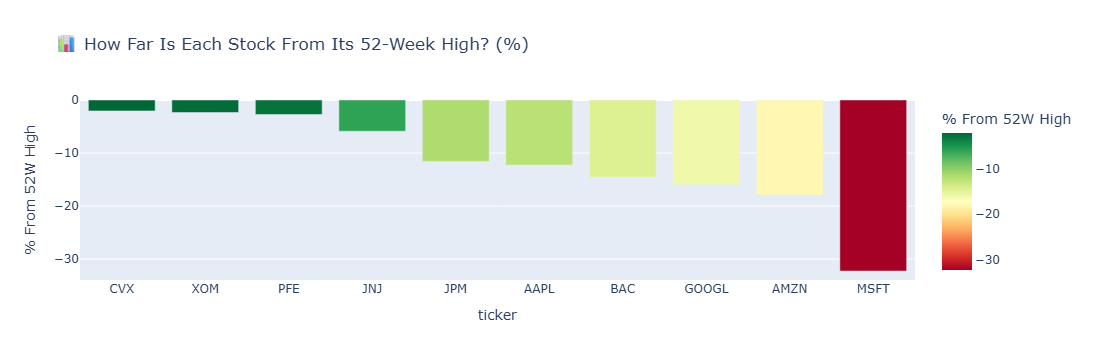

In [5]:
# Get the latest date per ticker
latest_date = df.groupby('ticker')['date'].max().reset_index()
latest_date.columns = ['ticker', 'latest_date']

# Merge back to get the closing price on that date
latest_prices = df.merge(latest_date, left_on=['ticker', 'date'], right_on=['ticker', 'latest_date'])
latest_prices = latest_prices[['ticker', 'close']]

# 52 week high
yearly_high = df.groupby('ticker')['high'].max().reset_index()
yearly_high.columns = ['ticker', '52w_high']

# Combine and calculate
proximity = latest_prices.merge(yearly_high, on='ticker')
proximity['pct_from_high'] = ((proximity['close'] - proximity['52w_high']) / proximity['52w_high']) * 100
proximity = proximity.sort_values('pct_from_high', ascending=False)

fig = px.bar(
    proximity,
    x='ticker',
    y='pct_from_high',
    color='pct_from_high',
    color_continuous_scale='RdYlGn',
    title='📊 How Far Is Each Stock From Its 52-Week High? (%)',
    labels={'pct_from_high': '% From 52W High'}
)
fig.show()

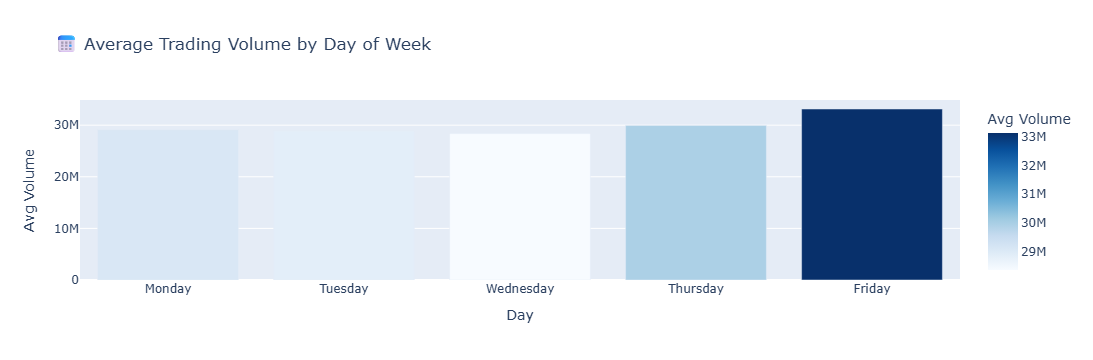

In [42]:
df['day_of_week'] = df['date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

volume_by_day = df.groupby('day_of_week')['volume'].mean().reset_index()
volume_by_day.columns = ['day_of_week', 'avg_volume']
volume_by_day['day_of_week'] = pd.Categorical(volume_by_day['day_of_week'], categories=day_order, ordered=True)
volume_by_day = volume_by_day.sort_values('day_of_week')

fig = px.bar(
    volume_by_day,
    x='day_of_week',
    y='avg_volume',
    color='avg_volume',
    color_continuous_scale='Blues',
    title='📅 Average Trading Volume by Day of Week',
    labels={'avg_volume': 'Avg Volume', 'day_of_week': 'Day'}
)
fig.show()